In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier, LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error, r2_score
from ucimlrepo import fetch_ucirepo

In [3]:
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296)
 
# Data (as pandas dataframes)
X = diabetes_130_us_hospitals_for_years_1999_2008.data.features
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets

# Combine features and target into a single dataframe
df = pd.concat([X, y], axis=1)

c:\Users\AhmedAlrashid\AppData\Local\Programs\Python\Python313\Lib\site-packages\ucimlrepo\fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


## Data Preparation
First, let's prepare our data by selecting the required features and preprocessing the target variable.

In [4]:
# Use the dataset you've already loaded
# Assuming df is already created from:
# df = pd.concat([X, y], axis=1)

# For classification, we need to convert the readmission to a binary target
# '<30' means readmitted within 30 days, '>30' means readmitted after 30 days, 'NO' means not readmitted
# Let's create a binary variable where 1 means readmitted (either <30 or >30) and 0 means not readmitted

df['readmitted_binary'] = df['readmitted'].apply(lambda x: 1 if x in ['<30', '>30'] else 0)

# Select features for our models
X_features = df[['age', 'diabetesMed']]
y_classification = df['readmitted_binary']
y_regression = df['readmitted_binary']  # Same target for regression to assess relationship

# Display the first few rows of our selected data
print("Selected features:")
print(X_features.head())
print("\nClassification target (readmitted or not):")
print(y_classification.head())

# Check value counts of our binary target
print("\nDistribution of readmission (binary):")
print(y_classification.value_counts())

Selected features:
       age diabetesMed
0   [0-10)          No
1  [10-20)         Yes
2  [20-30)         Yes
3  [30-40)         Yes
4  [40-50)         Yes

Classification target (readmitted or not):
0    0
1    1
2    0
3    0
4    0
Name: readmitted_binary, dtype: int64

Distribution of readmission (binary):
readmitted_binary
0    54864
1    46902
Name: count, dtype: int64


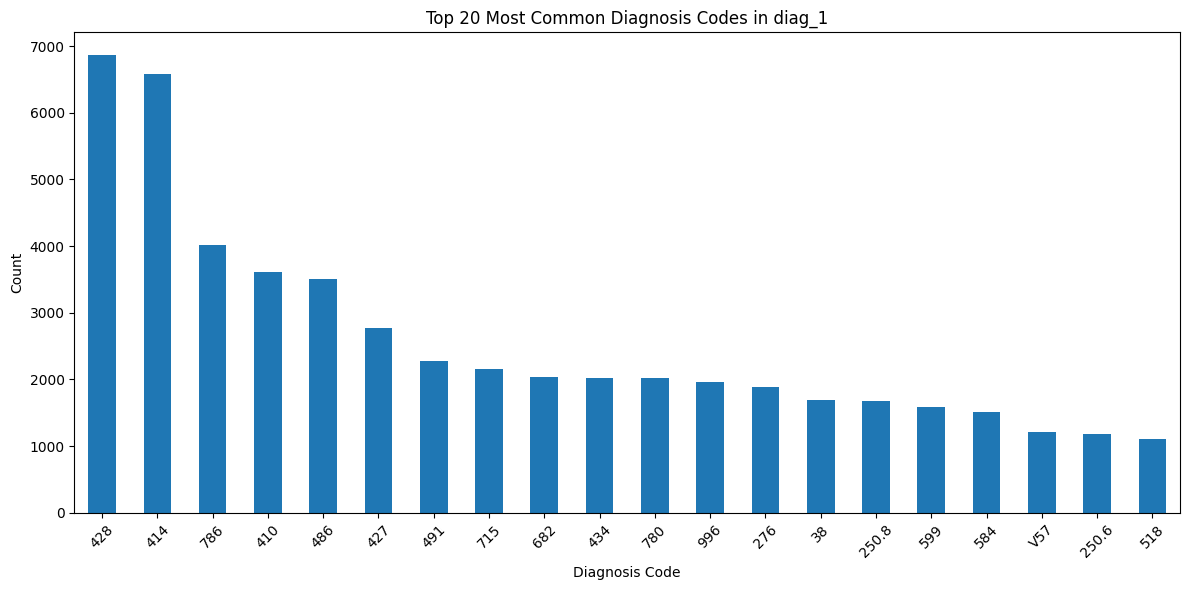

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Count the occurrences of each unique diagnosis code in diag_1
diag_counts = df['diag_1'].value_counts().sort_values(ascending=False)

# Display the top 20 most common diagnosis codes
top_20 = diag_counts.head(20)

plt.figure(figsize=(12, 6))
top_20.plot(kind='bar')
plt.title('Top 20 Most Common Diagnosis Codes in diag_1')
plt.xlabel('Diagnosis Code')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


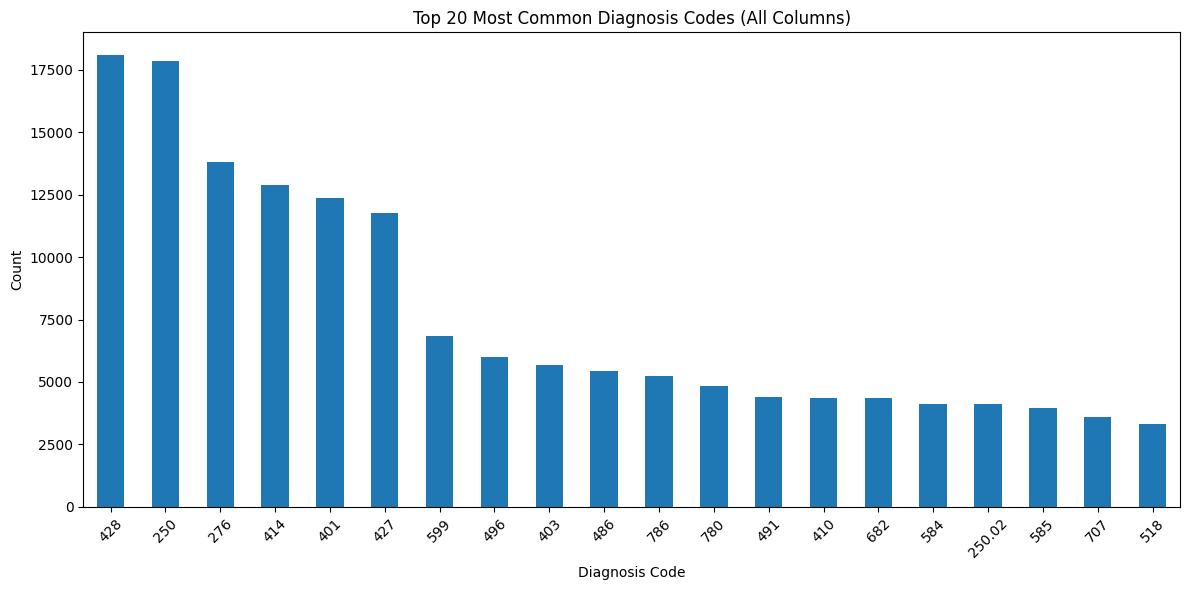

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Combine diagnosis columns into a single series and drop missing values
all_diag = pd.concat([df['diag_1'], df['diag_2'], df['diag_3']]).dropna()

# Count the occurrences of each unique diagnosis code across all three columns
diag_counts_all = all_diag.value_counts().sort_values(ascending=False)

# Display the top 20 most common diagnosis codes
top_20_all = diag_counts_all.head(20)

plt.figure(figsize=(12, 6))
top_20_all.plot(kind='bar')
plt.title('Top 20 Most Common Diagnosis Codes (All Columns)')
plt.xlabel('Diagnosis Code')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Feature Preprocessing
Next, we need to preprocess our features. The 'age' feature is categorical in this dataset (grouped in ranges), and 'diabetesMed' is also categorical (Yes/No).

In [9]:
# Check the unique values in our features
print("Unique values in 'age':", X_features['age'].unique())
print("Unique values in 'diabetesMed':", X_features['diabetesMed'].unique())

# Create preprocessing pipeline
# We'll use one-hot encoding for both categorical features
categorical_features = ['age', 'diabetesMed']
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features)
    ])

# Split the data
X_train, X_test, y_train_class, y_test_class = train_test_split(
    X_features, y_classification, test_size=0.3, random_state=42)

# Apply the same split for regression
y_train_reg, y_test_reg = y_train_class, y_test_class

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Unique values in 'age': ['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']
Unique values in 'diabetesMed': ['No' 'Yes']
Training set size: 71236 samples
Test set size: 30530 samples


## Stochastic Gradient Descent Classification Model
Now we'll create and train a classification model using Stochastic Gradient Descent to predict whether a patient will be readmitted.

Classification Report:
              precision    recall  f1-score   support

           0       0.54      1.00      0.70     16461
           1       0.00      0.00      0.00     14069

    accuracy                           0.54     30530
   macro avg       0.27      0.50      0.35     30530
weighted avg       0.29      0.54      0.38     30530


Confusion Matrix:
[[16461     0]
 [14069     0]]

Accuracy: 0.5392


c:\Users\AhmedAlrashid\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\AhmedAlrashid\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\AhmedAlrashid\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

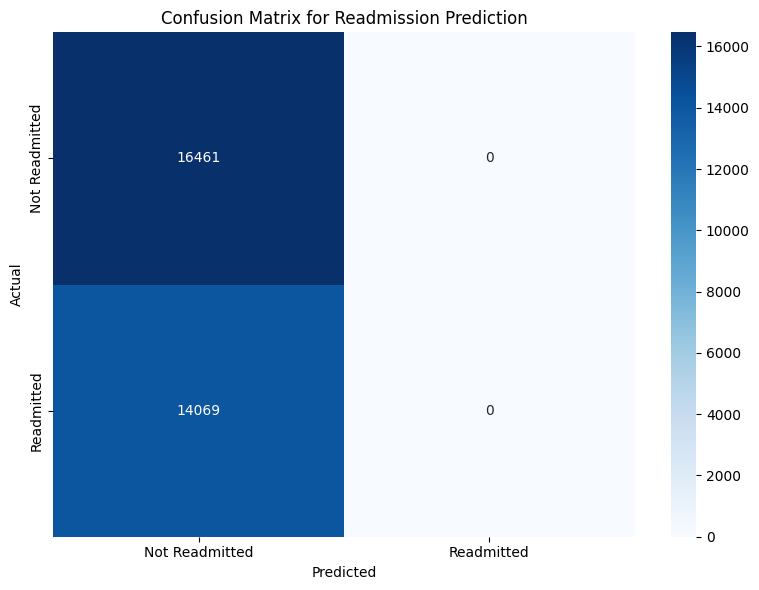

In [10]:
# Create SGD Classification pipeline
sgd_clf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SGDClassifier(loss='log_loss', random_state=42, max_iter=1000, tol=1e-3))
])

# Train the model
sgd_clf.fit(X_train, y_train_class)

# Evaluate on test data
y_pred_class = sgd_clf.predict(X_test)

# Print classification metrics
print("Classification Report:")
print(classification_report(y_test_class, y_pred_class))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test_class, y_pred_class)
print(cm)

accuracy = accuracy_score(y_test_class, y_pred_class)
print(f"\nAccuracy: {accuracy:.4f}")

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Readmission Prediction')
plt.tight_layout()
plt.show()

## Feature Importance for SGD Classification
Let's examine which features are most important for our classification model.

Feature Importance:
                Feature  Coefficient  Abs_Coefficient
6      cat__age_[70-80)     0.544525         0.544525
7      cat__age_[80-90)     0.530355         0.530355
5      cat__age_[60-70)     0.483877         0.483877
4      cat__age_[50-60)     0.352688         0.352688
1      cat__age_[20-30)     0.286126         0.286126
3      cat__age_[40-50)     0.284329         0.284329
8     cat__age_[90-100)     0.280485         0.280485
9  cat__diabetesMed_Yes     0.220658         0.220658
2      cat__age_[30-40)     0.049761         0.049761
0      cat__age_[10-20)    -0.016368         0.016368


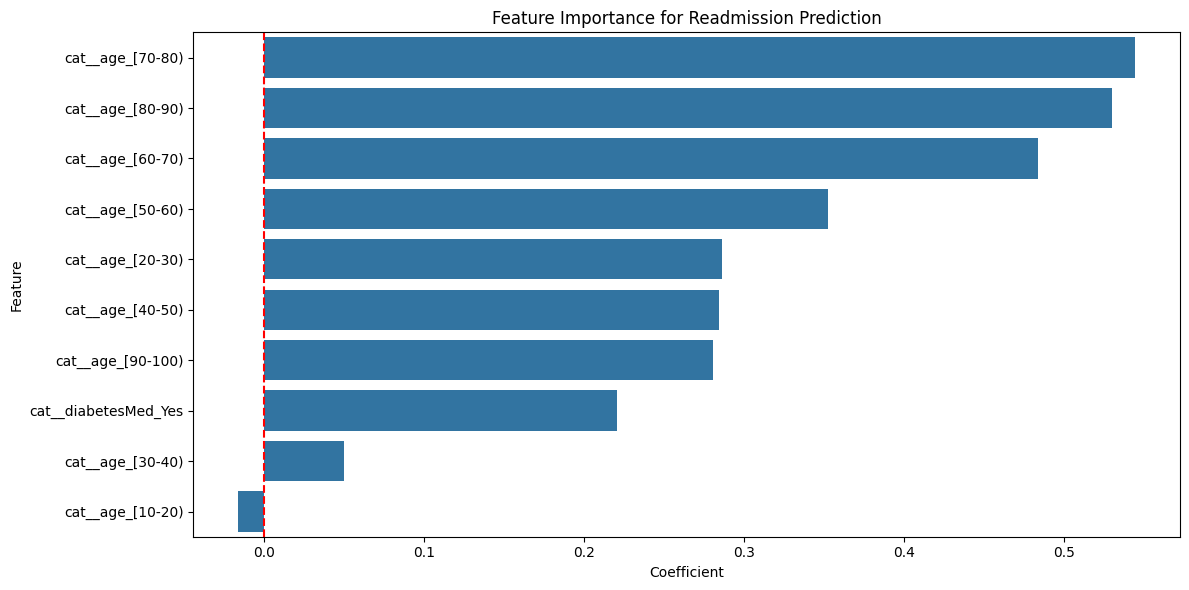

In [12]:
# Get feature names after preprocessing
feature_names = sgd_clf.named_steps['preprocessor'].get_feature_names_out()

# Get coefficients from the model
coefficients = sgd_clf.named_steps['classifier'].coef_[0]

# Create a DataFrame to display feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute coefficient value
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

print("Feature Importance:")
print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(12, 6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance)
plt.title('Feature Importance for Readmission Prediction')
plt.axvline(x=0, color='r', linestyle='--')
plt.tight_layout()
plt.show()

## Linear Regression Model for Age and Readmission
Now we'll create a linear regression model to explore the relationship between age and readmission status.

Age and readmission rate relationship:
   age_numeric  readmitted
0            5    0.180124
1           15    0.382055
2           25    0.450211
3           35    0.426755
4           45    0.444502
5           55    0.439557
6           65    0.462527
7           75    0.481203
8           85    0.482700
9           95    0.400286

Linear Regression Results:
Slope (coefficient): 0.001784
Intercept: 0.325801
Mean Squared Error: 0.004429
R² Score: 0.372128


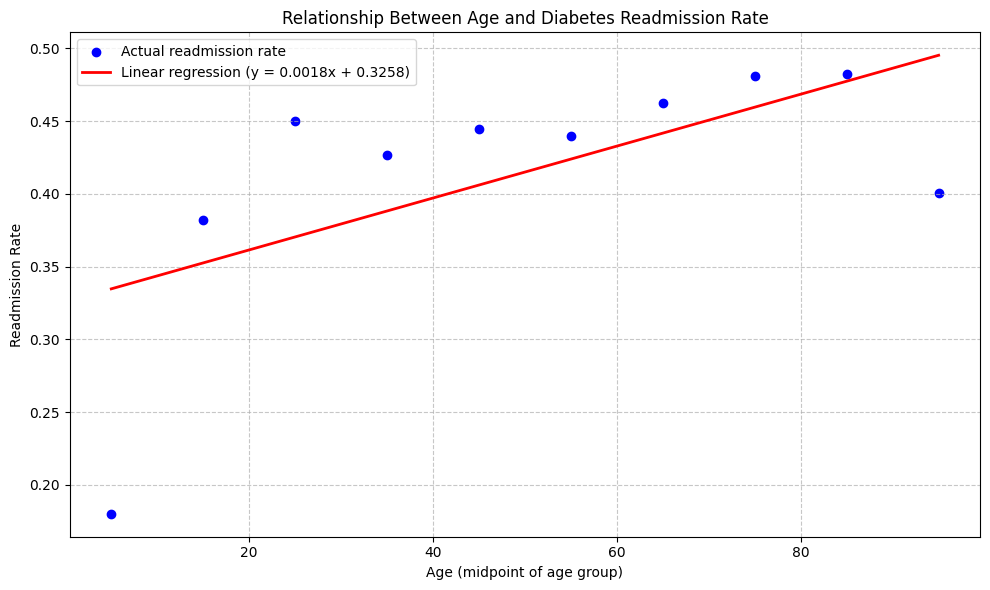

In [13]:
# Create a simpler dataset for visualization
# Convert age to numeric for regression
# First we need to create an ordinal mapping for the age groups
age_mapping = {
    '[0-10)': 5,
    '[10-20)': 15,
    '[20-30)': 25,
    '[30-40)': 35,
    '[40-50)': 45,
    '[50-60)': 55,
    '[60-70)': 65,
    '[70-80)': 75,
    '[80-90)': 85,
    '[90-100)': 95
}

# Create a copy to avoid modifying the original data
regression_data = X_features.copy()
regression_data['age_numeric'] = regression_data['age'].map(age_mapping)
regression_data['readmitted'] = y_classification

# Group by age and calculate mean readmission rate
age_readmission = regression_data.groupby('age_numeric')['readmitted'].mean().reset_index()

print("Age and readmission rate relationship:")
print(age_readmission)

# Create a linear regression model
X_lr = age_readmission[['age_numeric']]
y_lr = age_readmission['readmitted']

lr_model = LinearRegression()
lr_model.fit(X_lr, y_lr)

# Make predictions
y_lr_pred = lr_model.predict(X_lr)

# Calculate metrics
mse = mean_squared_error(y_lr, y_lr_pred)
r2 = r2_score(y_lr, y_lr_pred)

print(f"\nLinear Regression Results:")
print(f"Slope (coefficient): {lr_model.coef_[0]:.6f}")
print(f"Intercept: {lr_model.intercept_:.6f}")
print(f"Mean Squared Error: {mse:.6f}")
print(f"R² Score: {r2:.6f}")

# Visualize the relationship
plt.figure(figsize=(10, 6))
plt.scatter(age_readmission['age_numeric'], age_readmission['readmitted'], 
            color='blue', label='Actual readmission rate')
plt.plot(age_readmission['age_numeric'], y_lr_pred, color='red', linewidth=2, 
         label=f'Linear regression (y = {lr_model.coef_[0]:.4f}x + {lr_model.intercept_:.4f})')
plt.xlabel('Age (midpoint of age group)')
plt.ylabel('Readmission Rate')
plt.title('Relationship Between Age and Diabetes Readmission Rate')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

## Combined Analysis: Age, Diabetes Medication and Readmission
Finally, let's visualize how both age and diabetes medication status relate to readmission rates.

Classification Report:
              precision    recall  f1-score   support

           0       0.54      1.00      0.70     16461
           1       0.00      0.00      0.00     14069

    accuracy                           0.54     30530
   macro avg       0.27      0.50      0.35     30530
weighted avg       0.29      0.54      0.38     30530


Confusion Matrix:
[[16461     0]
 [14069     0]]

Accuracy: 0.5392

Accuracy by Age Group:
age
[0-10)      0.571429
[10-20)     0.585714
[20-30)     0.555556
[30-40)     0.544073
[40-50)      0.58774
[50-60)     0.561218
[60-70)     0.542982
[70-80)      0.57101
[80-90)     0.561783
[90-100)    0.546559
Name: Correct_Prediction, dtype: object

Accuracy by Diabetes Medication Status:
diabetesMed
No     0.549392
Yes    0.564765
Name: Correct_Prediction, dtype: object

Accuracy by Age and Diabetes Medication:
age       diabetesMed
[0-10)    No             0.333333
          Yes            0.636364
[10-20)   No                  0.5
          Yes

c:\Users\AhmedAlrashid\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\AhmedAlrashid\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\AhmedAlrashid\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

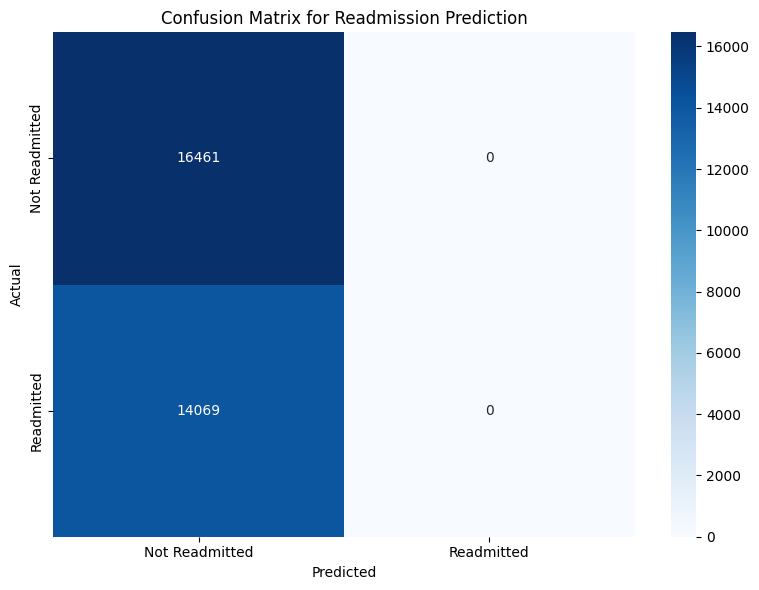

In [15]:
# Evaluate SGD Classification performance
# First, get predictions from our trained model
y_pred_class = sgd_clf.predict(X_test)

# Print classification metrics
print("Classification Report:")
print(classification_report(y_test_class, y_pred_class))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test_class, y_pred_class)
print(cm)

# Calculate and print accuracy
accuracy = accuracy_score(y_test_class, y_pred_class)
print(f"\nAccuracy: {accuracy:.4f}")

# Create a DataFrame to examine predictions
results_df = pd.DataFrame({
    'Actual': y_test_class,
    'Predicted': y_pred_class
})

# Add a column to check if prediction was correct
results_df['Correct_Prediction'] = results_df['Actual'] == results_df['Predicted']

# Add the original features from the test set
results_df = pd.concat([X_test.reset_index(drop=True), results_df], axis=1)

# Calculate accuracy by age group
age_accuracy = results_df.groupby('age')['Correct_Prediction'].mean()
print("\nAccuracy by Age Group:")
print(age_accuracy)

# Calculate accuracy by diabetes medication status
med_accuracy = results_df.groupby('diabetesMed')['Correct_Prediction'].mean()
print("\nAccuracy by Diabetes Medication Status:")
print(med_accuracy)

# Calculate accuracy by both factors
combined_accuracy = results_df.groupby(['age', 'diabetesMed'])['Correct_Prediction'].mean()
print("\nAccuracy by Age and Diabetes Medication:")
print(combined_accuracy)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Readmission Prediction')
plt.tight_layout()
plt.show()

Combined analysis of age, diabetes medication, and readmission:
    age_numeric diabetesMed  readmission_rate
0             5          No          0.107143
1             5         Yes          0.195489
2            15          No          0.307692
3            15         Yes          0.393333
4            25          No          0.388889
5            25         Yes          0.466160
6            35          No          0.355292
7            35         Yes          0.449982
8            45          No          0.392105
9            45         Yes          0.460635
10           55          No          0.395850
11           55         Yes          0.452130
12           65          No          0.418103
13           65         Yes          0.474817
14           75          No          0.423686
15           75         Yes          0.497945
16           85          No          0.403456
17           85         Yes          0.508982
18           95          No          0.359246
19           95 

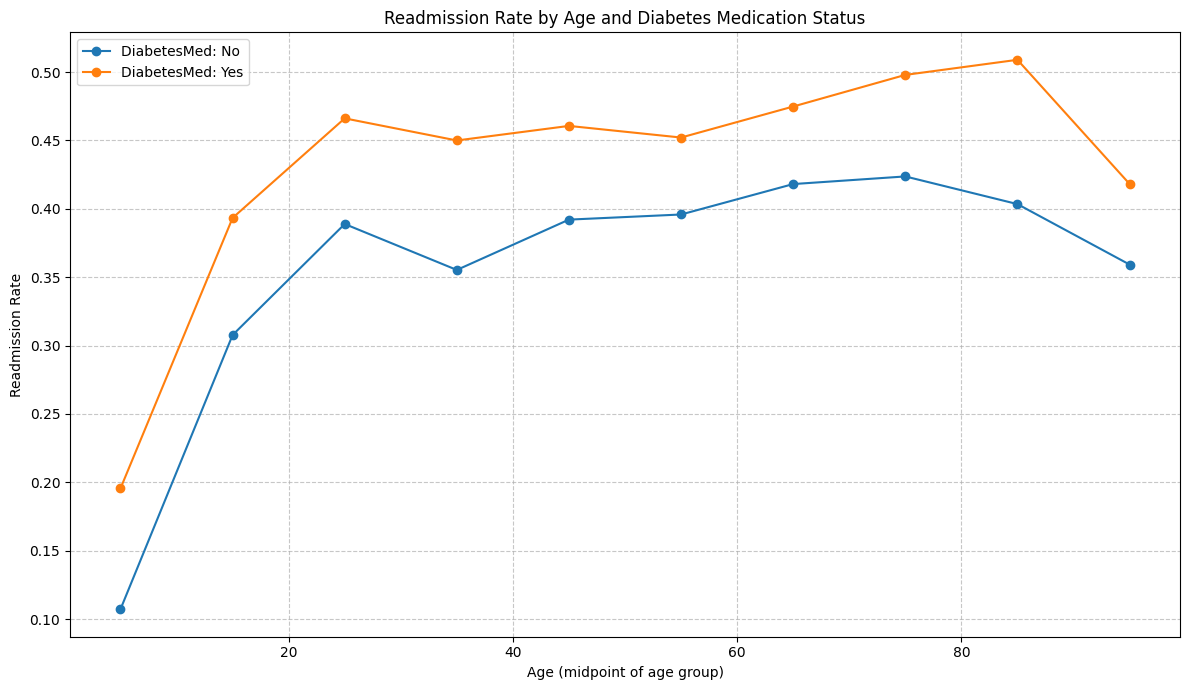

In [14]:
# Create a more detailed analysis with both factors
combined_data = df[['age', 'diabetesMed', 'readmitted_binary']].copy()
combined_data['age_numeric'] = combined_data['age'].map(age_mapping)

# Group by age and diabetesMed
combined_analysis = combined_data.groupby(['age_numeric', 'diabetesMed'])['readmitted_binary'].mean().reset_index()
combined_analysis = combined_analysis.rename(columns={'readmitted_binary': 'readmission_rate'})

print("Combined analysis of age, diabetes medication, and readmission:")
print(combined_analysis)

# Visualize the combined effect
plt.figure(figsize=(12, 7))
for med_status, group in combined_analysis.groupby('diabetesMed'):
    plt.plot(group['age_numeric'], group['readmission_rate'], 
             marker='o', linestyle='-', label=f'DiabetesMed: {med_status}')

plt.xlabel('Age (midpoint of age group)')
plt.ylabel('Readmission Rate')
plt.title('Readmission Rate by Age and Diabetes Medication Status')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()